In [1]:
# these warnings are fine. you can ignore them.
from copy import deepcopy
import random, math

from deeprobust.graph.data import Dataset as RDDataset
from deeprobust.graph.data import Pyg2Dpr, Pyg2Dpr
from deeprobust.graph.defense import GCNJaccard
from scipy.sparse import csr_matrix

import sys
sys.path.append('../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


In [2]:
jaccard_data = RDDataset(root='/tmp/', name="cora")
adj, features, labels = jaccard_data.adj, jaccard_data.features, jaccard_data.labels
idx_train, idx_val, idx_test = jaccard_data.idx_train, jaccard_data.idx_val, jaccard_data.idx_test

labels_copy = deepcopy(labels)
print(labels_copy.shape)

idx = np.concatenate([idx_train, idx_val, idx_test], axis=0)
np.sort(idx)

jaccard_in_feats = features.shape[1]
jaccard_h_feats = 64
jaccard_num_classes = labels.max() + 1

jaccard_model = get_model('../../../', jaccard_in_feats, jaccard_h_feats, jaccard_num_classes, 'cora', Models.GCNJACCARD)
jaccard_ground_truth = jaccard_model.test(idx_test)

Loading cora dataset...
Selecting 1 largest connected components
(2485,)
removed 572 edges in the original graph
Test set results: loss= 0.6584 accuracy= 0.7953


In [3]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()
data = data.to(device)

gcn_model = get_model('../', in_feats, h_feats, num_classes, 'cora', Models.GCN)
gcn_ground_truth = get_ground_truth(gcn_model, data, Models.GCN, testMask=True)
print(gcn_ground_truth)

gsaint_model = get_model('../', in_feats, h_feats, num_classes, 'cora', Models.GSAINT, data=dataset)
gsaint_ground_truth = get_ground_truth(gsaint_model, data, Models.GSAINT, testMask=True)
print(gsaint_ground_truth)

0.745
0.749


In [4]:
gat_model = get_model('../', in_feats, h_feats, num_classes, 'cora', Models.GAT)
gat_ground_truth = get_ground_truth(gat_model, data, Models.GAT, testMask=True)
print(gat_ground_truth)

0.756


In [5]:
gsage_dataset = Planetoid(root='/tmp/Cora', name='Cora')
gsage_data = gsage_dataset[0]
gsage_data = gsage_data.to(device, 'x', 'edge_index')

gsage_model = get_model('../', gsage_data.num_node_features, 64, 7, 'cora', Models.GSAGE)

gsage_ground_truth = get_ground_truth(gsage_model, gsage_data, Models.GSAGE, testMask = False)
print(gsage_ground_truth)

0.508


In [6]:
ptb_rates = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3]
gcn_vals = []
gat_vals = []
gsage_vals = []
gsaint_vals = []
jaccard_vals = []

In [7]:
homophilic_set = {label: [] for label in set(data.y.tolist())}

test_indices = torch.nonzero(data.test_mask, as_tuple=False).squeeze()
for i in test_indices:
    homophilic_set[data.y[i].item()].append(i.item())

In [8]:
c = 0.05
# 0.05, 0.1, 0.15, 0.2, 0.25

for p in ptb_rates:
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)
    train_mask = train_mask.to('cpu')
    test_mask = test_mask.to('cpu')
    
    blank_G = nx.Graph()

    for j in range(0, len(homophilic_set)):
        new_G = G.subgraph(homophilic_set[j])
        cc = sorted(nx.strongly_connected_components(new_G), key=len, reverse=True)
        for i in cc:
            s = set(i)
            if len(s) > 1 and nx.density(G.subgraph(i)) >= c:
                make_clique(blank_G, s)  

    budget = math.floor(p * (G.number_of_edges() / 2))
    print(budget)

    blank_G = blank_G.to_undirected()

    print(blank_G.number_of_edges())

    add_G = nx.Graph()
    
    edges = [edge for edge in blank_G.edges() if edge not in G.edges()]
    
    random.shuffle(edges)
    
    # Select budget number of edges and add them to add_G
    selected_edges = edges[:budget]
    add_G.add_edges_from(selected_edges)
    add_G = add_G.to_directed()
    add_edges = add_G.edges()

    for (i, j) in add_G.edges():
        G.add_edge(i, j)
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])

    # GCN
    acc = test_model(gcn_model, modified_graph, Models.GCN, testMask=True)
    gcn_vals.append(abs(acc - gcn_ground_truth))

    # GAT
    acc = test_model(gat_model, modified_graph, Models.GAT, testMask=True)
    gat_vals.append(abs(acc - gat_ground_truth))

    # GSAINT
    acc = test_model(gsaint_model, modified_graph, Models.GSAINT, testMask=True)
    gsaint_vals.append(abs(acc - gsaint_ground_truth))

    # GSAGE
    gsage_graph = modified_graph.to(device, 'x', 'edge_index')
    acc = get_ground_truth(gsage_model, gsage_graph, Models.GSAGE, testMask = False)
    gsage_vals.append(abs(acc - gsage_ground_truth))
        
    # # JACCARD
    # modified_adj = model.modified_adj # modified_adj is a torch.tensor
    # modified_adj = modified_adj.cpu().numpy()
    # modified_adj = csr_matrix(modified_adj)

    # atk_model = GCNJaccard(nfeat=features.shape[1],
    #       nhid=64,
    #       nclass=labels.max().item() + 1,
    #       dropout=0.5, device=device).to(device)
    # atk_model.fit(features, modified_adj, labels, idx_train, idx_val, patience=100, verbose=True)
    
    # atk_acc = atk_model.test(idx_test)

    # print(jaccard_data.adj)

    adj_matrix = nx.adjacency_matrix(G)
    adj_matrix_array = adj_matrix.toarray()
    adj_tensor = torch.tensor(adj_matrix_array).cpu().numpy()
    # jaccard_data = RDDataset(root='/tmp/', name="cora")
    # labels = jaccard_data.labels
    # print(adj_tensor.shape)
    # print(labels_copy.shape)
    # adj_tensor = csr_matrix(adj_tensor)
    
    # jaccard_model = get_model('../../../', jaccard_in_feats, jaccard_h_feats, jaccard_num_classes, 'cora', Models.GCNJACCARD)
    # jaccard_model.fit(features, adj_tensor, labels, idx_train, idx_val, patience=100, verbose=True)
    new_jaccard_model = GCNJaccard(nfeat=in_feats,
          nhid=64,
          nclass=jaccard_num_classes,
          dropout=0.5, device='cpu')
    new_jaccard_model.fit(np.array(x.cpu(), dtype=np.float64), adj_tensor, y.cpu(), train_mask.cpu(), idx_val=None, patience=100, verbose=False)
    acc = new_jaccard_model.test(test_mask.cpu())
    jaccard_vals.append(abs(acc - jaccard_ground_truth))

    
    # print(atk_acc)
    
    # jaccard_g = Dpr2Pyg(jaccard_data)[0].to('cpu')
    # jaccard_g = jaccard_g.to('cpu')
    # add_edges = [(int(edge[0]), int(edge[1])) for edge in add_edges]
    # add_edges_tensor = torch.tensor(add_edges, dtype=torch.long).t().to('cpu')
    # new_edge_index = torch.cat([jaccard_g.edge_index, add_edges_tensor], dim=1)
    # jaccard_g.edge_index = new_edge_index.to('cpu')
    # # add edge from add_edges list here
    # jaccard_new_data = Pyg2Dpr([jaccard_back])
    

    # print(dpr_data)
    # jaccard_model.fit(features, Pyg2Dpr(modified_graph), labels, [], [], threshold=0.01)
    # # model.eval()
    # acc = model.test(Pyg2Dpr(modified_graph).idx_test)
    # jaccard_vals.append(acc - jaccard_ground_truth)
    
    # number_added_edges(init_edges, final_edges, is_undirected=True)
    print("For c value:", c)

131
2536
removed 600 edges in the original graph
Test set results: loss= 0.6817 accuracy= 0.7930
For c value: 0.05
263
2536
removed 626 edges in the original graph
Test set results: loss= 0.6766 accuracy= 0.7960
For c value: 0.05
395
2536
removed 661 edges in the original graph
Test set results: loss= 0.6437 accuracy= 0.8090
For c value: 0.05
527
2536
removed 679 edges in the original graph
Test set results: loss= 0.6660 accuracy= 0.7940
For c value: 0.05
659
2536
removed 705 edges in the original graph
Test set results: loss= 0.6478 accuracy= 0.7970
For c value: 0.05
791
2536
removed 739 edges in the original graph
Test set results: loss= 0.6576 accuracy= 0.7950
For c value: 0.05
923
2536
removed 774 edges in the original graph
Test set results: loss= 0.6581 accuracy= 0.7960
For c value: 0.05
1055
2536
removed 783 edges in the original graph
Test set results: loss= 0.6545 accuracy= 0.8000
For c value: 0.05
1187
2536
removed 814 edges in the original graph
Test set results: loss= 0.649

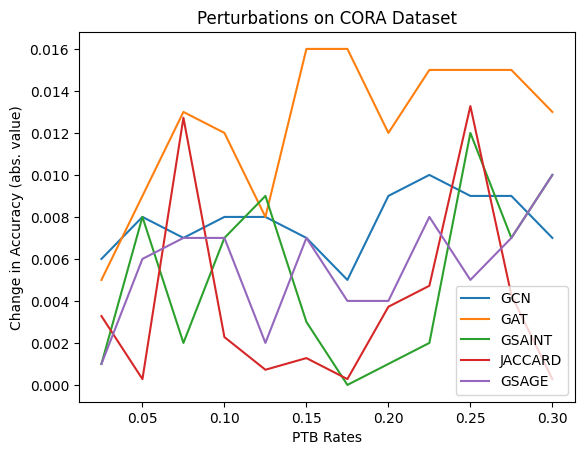

In [9]:
import matplotlib.pyplot as plt

# X-axis values: the ptb_rates
ptb_rates = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3]

# Plot each line with a label
plt.plot(ptb_rates, gcn_vals, label="GCN")
plt.plot(ptb_rates, gat_vals, label="GAT")
plt.plot(ptb_rates, gsaint_vals, label="GSAINT")
plt.plot(ptb_rates, jaccard_vals, label="JACCARD")
plt.plot(ptb_rates, gsage_vals, label="GSAGE")

# Adding labels and title
plt.xlabel('PTB Rates')
plt.ylabel('Change in Accuracy (abs. value)')
plt.title('Perturbations on CORA Dataset')
plt.legend()

# Show the plot
output_path = "./data/cora_graph.png"
plt.savefig(output_path)

plt.show()